In [140]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM
from tensorflow.keras.layers import Dense, Dropout

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')



In [141]:
train_df = pd.read_csv("/content/drive/MyDrive/AI_part3_Final/train_movie_review.csv")
val_df = pd.read_csv("/content/drive/MyDrive/AI_part3_Final/val_movie_review.csv")
test_df = pd.read_csv("/content/drive/MyDrive/AI_part3_Final/test_movie_review.csv")

In [142]:
print("Training Shape:", train_df.shape)
print("Validation Shape:", val_df.shape)
print("Testing Shape:", test_df.shape)

Training Shape: (35000, 3)
Validation Shape: (5000, 3)
Testing Shape: (10000, 3)


In [143]:
train_df.head(10)

,Unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0
3,6703,A lot people get hung up on this films tag as ...,1
4,28168,I was a fan of Buffy and hoped it would come t...,0
5,39689,Arthur is middle aged rich 'kid' who drinks li...,1
6,41256,"Best fan boy movie I've ever watched save ""Fre...",1
7,27102,"""The King is Alive"" is a flawed and contrived ...",0
8,41833,Note that I did not say that it is better...ju...,1
9,31135,I'm a huge Zack Allan fan and was disappointed...,0


**Data Cleaning**

In [144]:
print(train_df.isnull().sum())
print(val_df.isnull().sum())
print(test_df.isnull().sum())

Unnamed: 0    0
review        0
sentiment     0
dtype: int64
Unnamed: 0    0
review        0
sentiment     0
dtype: int64
Unnamed: 0    0
review        0
sentiment     0
dtype: int64


In [145]:
train_df['sentiment'].value_counts()

,count
sentiment,
0,17584
1,17416


In [206]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r'\d+', '', text)

    words = text.split()

    important_words = {"not", "no", "very", "but", "never"}

    words = [
        word for word in words
        if word not in stop_words or word in important_words
    ]

    return " ".join(words)

train_df['clean_review'] = train_df['review'].apply(clean_text)

val_df['clean_review'] = val_df['review'].apply(clean_text)

test_df['clean_review'] = test_df['review'].apply(clean_text)

print("Enhanced preprocessing completed!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Enhanced preprocessing completed!


In [147]:
X_train = train_df['clean_review']
y_train = train_df['sentiment']

X_val = val_df['clean_review']
y_val = val_df['sentiment']

X_test = test_df['clean_review']
y_test = test_df['sentiment']

In [217]:
max_words = 50000

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [218]:
X_train_seq = tokenizer.texts_to_sequences(X_train)

X_val_seq = tokenizer.texts_to_sequences(X_val)

X_test_seq = tokenizer.texts_to_sequences(X_test)

In [233]:
max_length = 300

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

**Data Visualization**

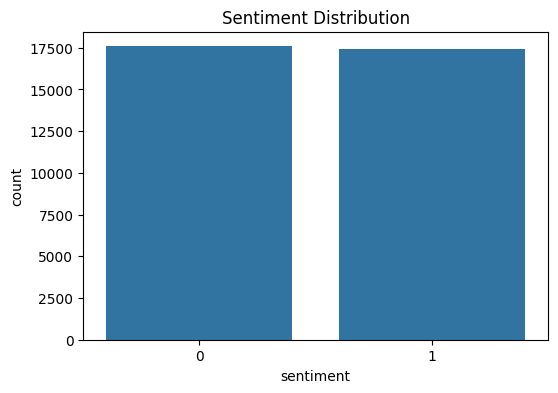

In [151]:
plt.figure(figsize=(6,4))

sns.countplot(x='sentiment', data=train_df)

plt.title("Sentiment Distribution")
plt.show()

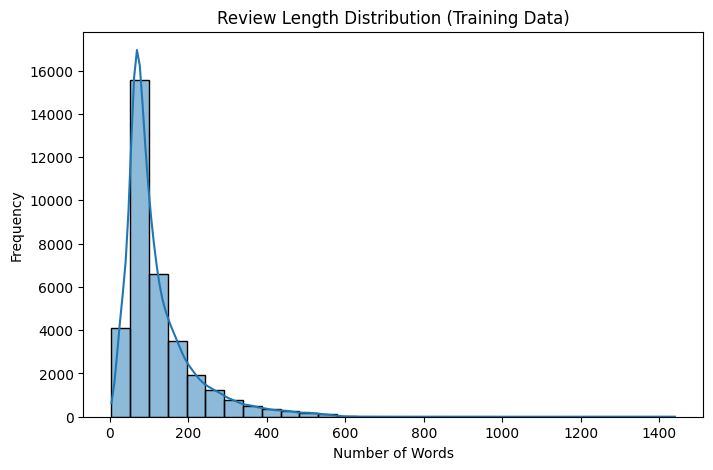

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

train_df['review_length'] = train_df['clean_review'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.histplot(train_df['review_length'], bins=30, kde=True)
plt.title("Review Length Distribution (Training Data)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [153]:
from collections import Counter
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

train_df['temp_clean'] = train_df['review'].apply(clean_text)

all_words = " ".join(train_df['temp_clean']).split()
word_counts = Counter(all_words)

common_words = word_counts.most_common(20)

print(common_words)

[('the', 464850), ('and', 223814), ('a', 223610), ('of', 200877), ('to', 186435), ('is', 147134), ('in', 129131), ('it', 107093), ('i', 107014), ('this', 104472), ('that', 95503), ('br', 80651), ('was', 66726), ('as', 63943), ('for', 60585), ('with', 60488), ('movie', 58313), ('but', 57146), ('film', 52300), ('on', 46632)]


In [154]:
positive_words = " ".join(train_df[train_df['sentiment'] == 1]['temp_clean']).split()
negative_words = " ".join(train_df[train_df['sentiment'] == 0]['temp_clean']).split()

pos_counts = Counter(positive_words).most_common(15)
neg_counts = Counter(negative_words).most_common(15)

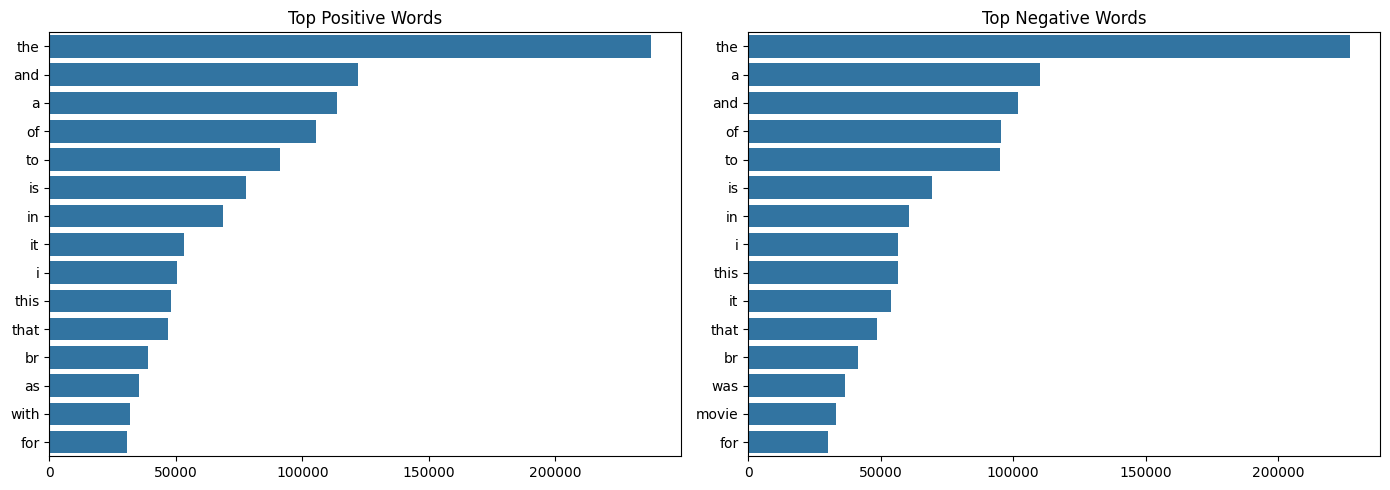

In [155]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

words_pos = [w for w, c in pos_counts]
counts_pos = [c for w, c in pos_counts]

sns.barplot(x=counts_pos, y=words_pos, ax=axes[0])
axes[0].set_title("Top Positive Words")

words_neg = [w for w, c in neg_counts]
counts_neg = [c for w, c in neg_counts]

sns.barplot(x=counts_neg, y=words_neg, ax=axes[1])
axes[1].set_title("Top Negative Words")

plt.tight_layout()
plt.show()

**Simple RNN**

In [171]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dropout, Dense
from tensorflow.keras.optimizers import Adam

rnn_model = Sequential()

rnn_model.add(Input(shape=(max_length,)))

rnn_model.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        mask_zero=True
    )
)

rnn_model.add(SimpleRNN(128))
rnn_model.add(Dropout(0.5))

rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [168]:
rnn_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_14 (SimpleRNN)       │ (None, 200, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_15 (SimpleRNN)       │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,605,313 (9.94 MB)

 Trainable params: 2,605,313 (9.94 MB)

 Non-trainable params: 0 (0.00 B)

In [172]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [173]:
history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 112s 201ms/step - accuracy: 0.7198 - loss: 0.5325 - val_accuracy: 0.6104 - val_loss: 0.7277
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 141s 199ms/step - accuracy: 0.8485 - loss: 0.3588 - val_accuracy: 0.8524 - val_loss: 0.3617
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 109s 199ms/step - accuracy: 0.9118 - loss: 0.2346 - val_accuracy: 0.8430 - val_loss: 0.3968
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 110s 201ms/step - accuracy: 0.9378 - loss: 0.1683 - val_accuracy: 0.8202 - val_loss: 0.4546


In [175]:
rnn_loss, rnn_acc = rnn_model.evaluate(X_test_pad, y_test)
print("RNN Test Accuracy:", rnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.8553 - loss: 0.3593
RNN Test Accuracy: 0.8553000092506409


In [176]:
rnn_pred = (rnn_model.predict(X_test_pad) > 0.4).astype(int).flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step


In [177]:
print(train_df['sentiment'].value_counts())

sentiment
0    17584
1    17416
Name: count, dtype: int64


In [179]:
print(classification_report(y_test, rnn_pred))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      4961
           1       0.84      0.87      0.86      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



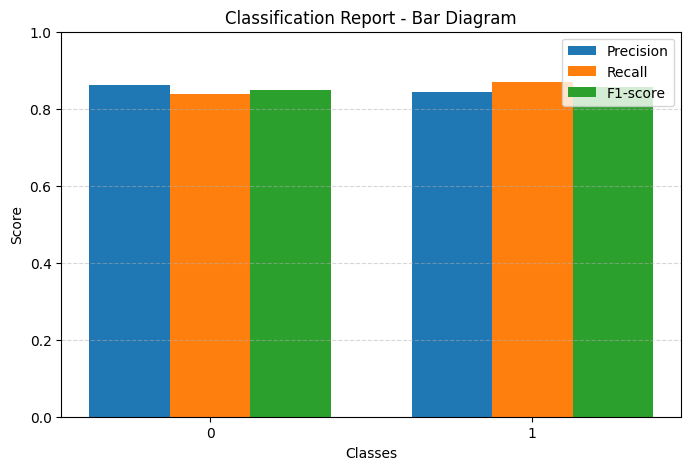

In [180]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

report = classification_report(y_test, rnn_pred, output_dict=True)

classes = [label for label in report.keys() if label.isdigit()]

precision = [report[c]['precision'] for c in classes]
recall = [report[c]['recall'] for c in classes]
f1_score = [report[c]['f1-score'] for c in classes]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(8,5))

plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1_score, width, label='F1-score')

plt.xlabel("Classes")
plt.ylabel("Score")
plt.title("Classification Report - Bar Diagram")
plt.xticks(x, classes)
plt.ylim(0, 1)
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

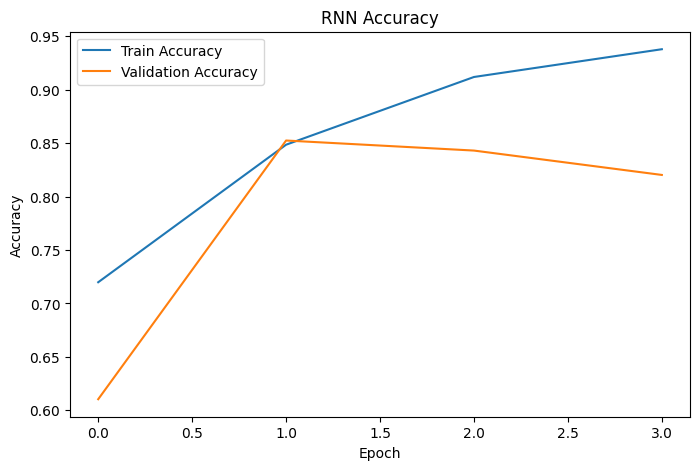

In [181]:
plt.figure(figsize=(8,5))

plt.plot(history_rnn.history['accuracy'], label='Train Accuracy')

plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')

plt.title("RNN Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

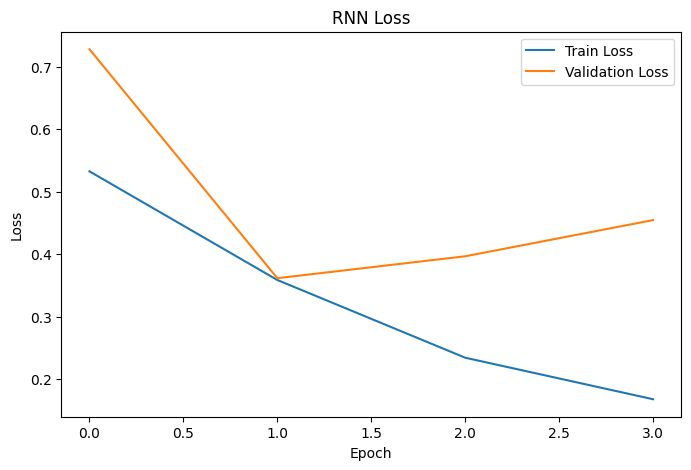

In [182]:
plt.figure(figsize=(8,5))

plt.plot(history_rnn.history['loss'], label='Train Loss')

plt.plot(history_rnn.history['val_loss'], label='Validation Loss')

plt.title("RNN Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

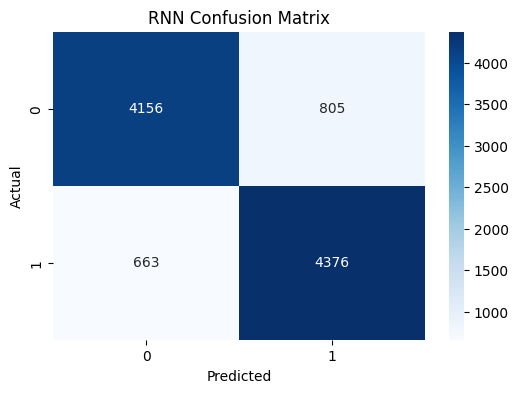

In [183]:
cm = confusion_matrix(y_test, rnn_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("RNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [184]:
for i in range(5):
    print("Text:", X_test_pad[i])
    print("Actual:", y_test[i])
    print("Predicted:", rnn_pred[i])
    print("-"*50)

Text: [   16   319     1   561    44  8906  6260    44   326   133   149  3203
    30     5    47     1    50 11885    69  8953     1   185   421     1
     7   472   517  1563    53  1081   461    53    63  1100     7  1038
   282   185   421     6    82   782     1   282   782  1986  6119  9041
  1081  2375 13601  9955   316  1081  9550   434  6454   374  1081 17220
     1   421  6454   647   107   482   434  1886 10282 13514  1081   134
 13204  3584    24    51     1    51  1502     1   436  3584     1   119
   133     1     1  2394  4246     1  7574   439  1063     1    74   282
   782  3286     1     1   439  4828  4828 15385     1     1 14939    91
   277  8953     1   782   251   282   175   102   843     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0   

In [185]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

test_sentences = [
    "I absolutely loved this movie, it was amazing!",
    "This product is fantastic and works really well!",
    "I hate this so much, worst experience ever.",
    "This is completely useless and very disappointing.",
    "Oh great, another amazing update that broke everything."
]

sequences = tokenizer.texts_to_sequences(test_sentences)

padded = pad_sequences(sequences, maxlen=max_length, padding='post')

predictions = rnn_model.predict(padded)

print("\n Error Analysis Results:\n")

for i, sentence in enumerate(test_sentences):
    pred_label = int((predictions[i] > 0.5).astype(int))

    sentiment = "Positive (1)" if pred_label == 1 else "Negative (0)"

    print(f"Sentence {i+1}: {sentence}")
    print(f"Predicted: {sentiment}")
    print(f"Confidence: {predictions[i][0]:.4f}")
    print("-" * 60)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step

 Error Analysis Results:

Sentence 1: I absolutely loved this movie, it was amazing!
Predicted: Positive (1)
Confidence: 0.9103
------------------------------------------------------------
Sentence 2: This product is fantastic and works really well!
Predicted: Positive (1)
Confidence: 0.8683
------------------------------------------------------------
Sentence 3: I hate this so much, worst experience ever.
Predicted: Negative (0)
Confidence: 0.0578
------------------------------------------------------------
Sentence 4: This is completely useless and very disappointing.
Predicted: Negative (0)
Confidence: 0.0167
------------------------------------------------------------
Sentence 5: Oh great, another amazing update that broke everything.
Predicted: Positive (1)
Confidence: 0.9408
------------------------------------------------------------


**LSTM Baseline**

In [236]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dropout, Dense, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_length,)))

lstm_model.add(Embedding(
    input_dim=max_words,
    output_dim=128,
    mask_zero=True
))

lstm_model.add(Bidirectional(LSTM(128, return_sequences=True)))
lstm_model.add(BatchNormalization())
lstm_model.add(Dropout(0.4))

lstm_model.add(Bidirectional(LSTM(64)))

lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0003),
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_21 (Embedding)        │ (None, 300, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 300, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 300, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 300, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,828,673 (26.05 MB)

 Trainable params: 6,828,161 (26.05 MB)

 Non-trainable params: 512 (2.00 KB)

In [237]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 1696s 3s/step - accuracy: 0.8362 - loss: 0.3618 - val_accuracy: 0.8908 - val_loss: 0.2884
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 1708s 3s/step - accuracy: 0.9429 - loss: 0.1591 - val_accuracy: 0.8800 - val_loss: 0.2874
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 1666s 3s/step - accuracy: 0.9760 - loss: 0.0725 - val_accuracy: 0.8748 - val_loss: 0.3746
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 1705s 3s/step - accuracy: 0.9878 - loss: 0.0364 - val_accuracy: 0.8588 - val_loss: 0.5438


In [225]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)

print("Test Loss:", lstm_loss)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.8841 - loss: 0.2990
Test Loss: 0.2989984452724457
Test Accuracy: 0.8841000199317932


In [226]:
lstm_pred = lstm_model.predict(X_test_pad)
lstm_pred = (lstm_pred > 0.5).astype(int).flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step


In [227]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lstm_pred))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



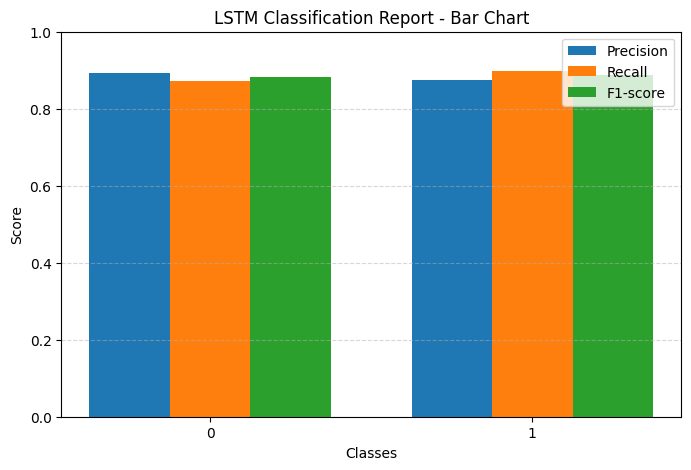

In [228]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

report = classification_report(y_test, lstm_pred, output_dict=True)

classes = [label for label in report.keys() if label.isdigit()]

precision = [report[c]['precision'] for c in classes]
recall = [report[c]['recall'] for c in classes]
f1_score = [report[c]['f1-score'] for c in classes]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(8,5))

plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1_score, width, label='F1-score')

plt.xlabel("Classes")
plt.ylabel("Score")
plt.title("LSTM Classification Report - Bar Chart")
plt.xticks(x, classes)
plt.ylim(0, 1)
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

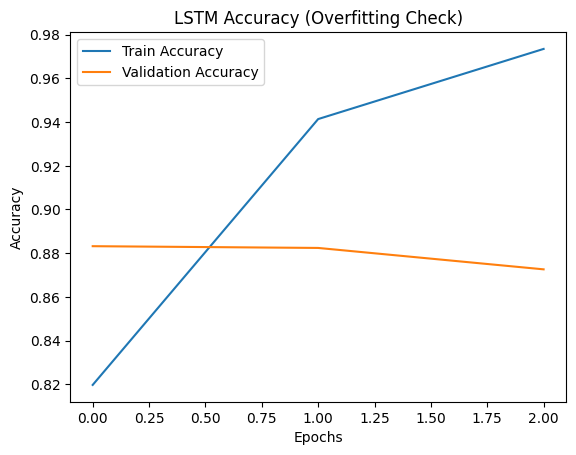

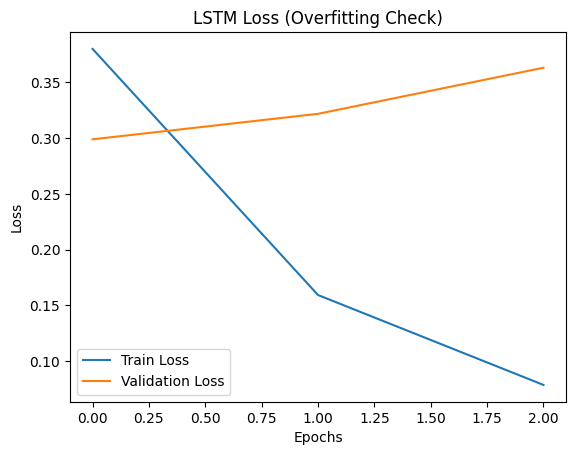

In [229]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("LSTM Accuracy (Overfitting Check)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("LSTM Loss (Overfitting Check)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

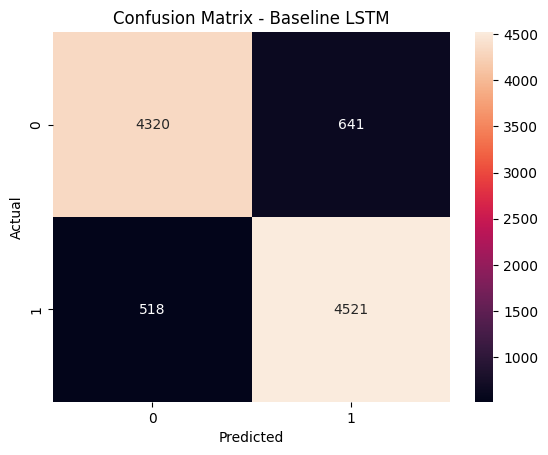

In [230]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, lstm_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Baseline LSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [231]:
print("Misclassified examples:\n")

count = 0
for i in range(len(X_test_pad)):
    if lstm_pred[i] != y_test[i]:
        print("Example:", i)
        print("Actual:", y_test[i])
        print("Predicted:", lstm_pred[i])
        print("Text (encoded):", X_test_pad[i])
        print("-"*50)
        count += 1
    if count == 5:
        break

Misclassified examples:

Example: 8
Actual: 0
Predicted: 1
Text (encoded): [  579   122    62   487  1203    90   444   669   315  3235   119   101
   318   165     1    62   353   445   487    78  1065   669   370    12
   475   157    26    94   252  2606  2131    13  1606     1   250     1
     1   113   293  3721    44     1     2  3556    34    92   118     1
 26859   159  1454  3863    30    19    52    30  2113    19    52   312
  1065   892   207   312   236  1249 15965 14494     2  6133   101   991
 35344    30   599 12613   122     5   170   405  8232   125   468  2032
  8914 10971     7  2131   666   519    28    86   287    37     7   203
  2151    29  1922    48 49053  2135     6   174 25477    80  5952     1
    47    28   143 11511 41293     2   311    26   918  3494   196  2945
     1 27966   564  4773   789     1   328  4168  1487  8914  6359   602
    80    52  2006  3898  7657    21   336    58 12300   165   162    15
  1343  1930   774   496    60    48   410  2044 

**LSTM with word2vec**

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 24.2 MB/s eta 0:00:00


In [ ]:
import gensim.downloader as api

word2vec = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


In [ ]:
import numpy as np

embedding_dim = 100

word_index = tokenizer.word_index

embedding_matrix = np.zeros((max_words, embedding_dim))

for word, i in word_index.items():
    if i < max_words:
        if word in word2vec:
            embedding_matrix[i] = word2vec[word]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense

lstm_V_model = Sequential()

lstm_V_model.add(Input(shape=(max_length,)))

lstm_V_model.add(
    Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=True
    )
)

lstm_V_model.add(LSTM(64, return_sequences=True))
lstm_V_model.add(Dropout(0.3))

lstm_V_model.add(LSTM(32))
lstm_V_model.add(Dropout(0.5))

lstm_V_model.add(Dense(1, activation='sigmoid'))

lstm_V_model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 200, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 200, 64)        │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,054,689 (4.02 MB)

 Trainable params: 1,054,689 (4.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_V_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
history_lstm_glove = lstm_V_model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop]
)

Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 303s 274ms/step - accuracy: 0.7986 - loss: 0.4327 - val_accuracy: 0.8626 - val_loss: 0.3284
Epoch 2/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 323s 274ms/step - accuracy: 0.9008 - loss: 0.2553 - val_accuracy: 0.8898 - val_loss: 0.2764
Epoch 3/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 299s 273ms/step - accuracy: 0.9276 - loss: 0.1940 - val_accuracy: 0.8946 - val_loss: 0.2620
Epoch 4/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 332s 283ms/step - accuracy: 0.9478 - loss: 0.1457 - val_accuracy: 0.8898 - val_loss: 0.3295
Epoch 5/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 297s 271ms/step - accuracy: 0.9645 - loss: 0.1032 - val_accuracy: 0.8864 - val_loss: 0.3972


In [ ]:
lstm_w2v_loss, lstm_w2v_acc = lstm_V_model.evaluate(X_test_pad, y_test)

print("Word2Vec LSTM Accuracy:", lstm_w2v_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - accuracy: 0.8932 - loss: 0.2571
Word2Vec LSTM Accuracy: 0.8931999802589417


In [ ]:
lstm_pred = lstm_model.predict(X_test_pad)
lstm_pred = (lstm_pred > 0.5).astype(int)
lstm_pred = lstm_pred.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step


In [ ]:
for i in range(5):
    print("Text:", X_test[i])
    print("Actual:", y_test[i])
    print("Predicted:", lstm_pred[i])
    print("-"*50)

Text: i really liked this summerslam due to the look of the arena the curtains and just the look overall was interesting to me for some reason anyways this could have been one of the best summerslams ever if the wwf didnt have lex luger in the main event against yokozuna now for its time it was ok to have a huge fat man vs a strong man but im glad times have changed it was a terrible main event just like every match luger is in is terrible other matches on the card were razor ramon vs ted dibiase steiner brothers vs heavenly bodies shawn michaels vs curt hening this was the event where shawn named his big monster of a body guard diesel irs vs  kid bret hart first takes on doink then takes on jerry lawler and stuff with the harts and lawler was always very interesting then ludvig borga destroyed marty jannetty undertaker took on giant gonzalez in another terrible match the smoking gunns and tatanka took on bam bam bigelow and the headshrinkers and yokozuna defended the world title again

In [ ]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)

print("LSTM Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.8906 - loss: 0.2760
LSTM Accuracy: 0.8906000256538391


In [ ]:
lstm_pred = lstm_model.predict(X_test_pad)

lstm_pred = (lstm_pred > 0.5).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step


In [ ]:
print(classification_report(y_test, lstm_pred))

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



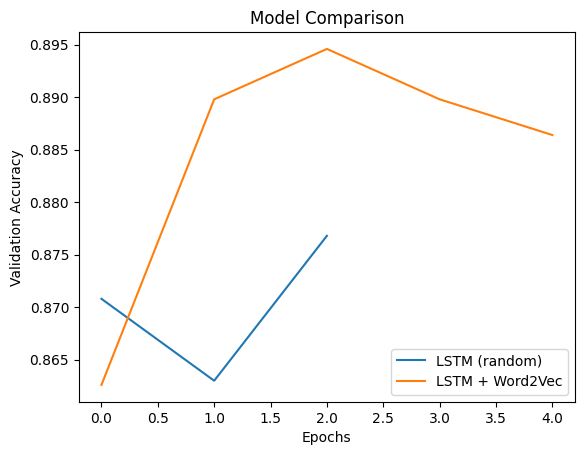

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_lstm.history['val_accuracy'], label='LSTM (random)')
plt.plot(history_lstm_glove.history['val_accuracy'], label='LSTM + Word2Vec')

plt.legend()
plt.title("Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.show()

**Model Comparision**

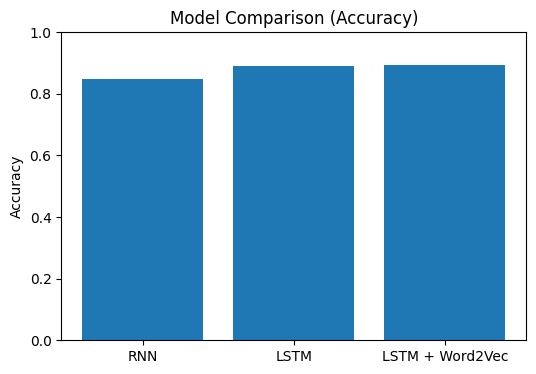

In [ ]:
import matplotlib.pyplot as plt

models = ['RNN', 'LSTM', 'LSTM + Word2Vec']

accuracies = [rnn_acc, lstm_acc, lstm_w2v_acc]

plt.figure(figsize=(6,4))

plt.bar(models, accuracies)

plt.title("Model Comparison (Accuracy)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

In [ ]:
def plot_history(history, title):

    plt.figure(figsize=(6,4))

    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

    plt.title(title + " - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


    plt.figure(figsize=(6,4))

    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')

    plt.title(title + " - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

In [ ]:
def predict_sentiment(text):

    text = clean_text(text)

    sequence = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post'
    )

    prediction = lstm_model.predict(padded)[0][0]

    if prediction >= 0.5:
        return "Positive Review"
    else:
        return "Negative Review"

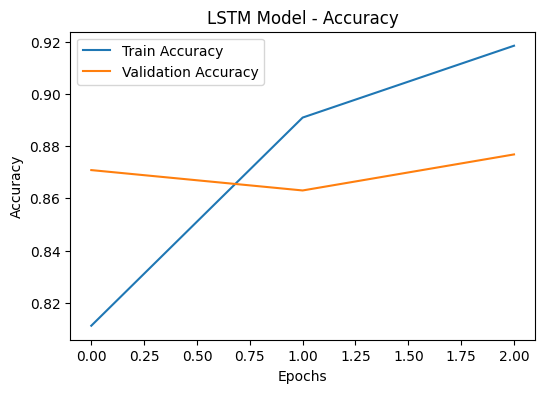

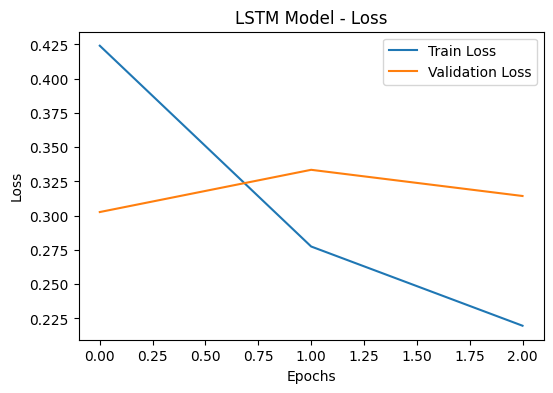

In [ ]:
plot_history(history_lstm, "LSTM Model")

In [ ]:
sample = "This movie was amazing and very emotional"

print(predict_sentiment(sample))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Positive Review


In [ ]:
text = "This movie is terrible and boring"

seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=200, padding='pre')

pred = lstm_model.predict(pad)
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
[[0.01759376]]


In [ ]:
!pip install gradio

In [ ]:

import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_sentiment(text):

    seq = tokenizer.texts_to_sequences([text])

    pad = pad_sequences(seq, maxlen=200, padding='pre')

    pred = lstm_model.predict(pad)[0][0]

    if pred > 0.5:
        return f"Positive 😊 (score: {pred:.2f})"
    else:
        return f"Negative 😞 (score: {pred:.2f})"

def gradio_predict(text):
    return predict_sentiment(text)


with gr.Blocks(theme=gr.themes.Soft()) as interface:

    gr.Markdown(
        """
        # 🎬 IMDb Movie Review Sentiment Analyzer
        ### Predict whether a review is **Positive 😊** or **Negative 😞**
        """
    )

    with gr.Row():

        with gr.Column():

            input_box = gr.Textbox(
                label="Enter Movie Review",
                placeholder="Type something like: This movie was absolutely amazing!",
                lines=4
            )

            btn = gr.Button("Predict Sentiment 🚀")

            gr.Examples(
                examples=[
                    "This movie was fantastic, I loved it!",
                    "Worst movie I have ever seen.",
                    "The plot was okay but acting was great.",
                    "I would not recommend this film."
                ],
                inputs=input_box
            )

        with gr.Column():

            output_box = gr.Textbox(
                label="Prediction Result",
                interactive=False
            )

    btn.click(
        fn=gradio_predict,
        inputs=input_box,
        outputs=output_box
    )

interface.launch()

/tmp/ipykernel_6688/1078248154.py:22: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as interface:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fcb7f7c45f33c05000.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
